# Food Delivery Data Visualization Portfolio — Day 14

## Objective
Use **Matplotlib and Seaborn** to build a visualization portfolio for the Food Delivery Business Performance Dataset.

The portfolio investigates:
- Orders and revenue trends over time
- Differences across cities and cuisines
- Marketing spend vs. revenue
- Delivery time vs. customer ratings
- Weather and order-channel effects on performance
- Distributions and outliers
- Correlations among numerical variables

Each visualization is followed by a short interpretation explaining the business insight.


## 1. Import Libraries and Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Load the dataset
df = pd.read_csv("Day14_Food_Delivery_Visualization_Dataset.csv")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (360, 16)


,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,"67,374.27","28,150.42","7,859.02",30.70,4.38,45.10
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,"50,312.93","20,907.75","2,604.03",38.00,4.34,40.40
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,"71,929.08","18,930.77","3,613.92",25.30,4.65,43.00
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,"58,803.81","35,926.51","10,092.64",32.60,4.48,41.20
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,"40,416.50","23,514.60","2,500.30",39.30,4.16,35.90


## 2. Basic Dataset Inspection

In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data_Type"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("Missing_Count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe(include="all").T)


Columns:
['Order_Batch_ID', 'Date', 'Month', 'Day', 'City', 'Cuisine', 'Order_Channel', 'Weather', 'Orders', 'Average_Order_Value', 'Revenue', 'Marketing_Spend', 'Discounts', 'Avg_Delivery_Minutes', 'Customer_Rating', 'Repeat_Customer_Percent']

Data types:


,Data_Type
Order_Batch_ID,object
Date,object
Month,object
Day,object
City,object
Cuisine,object
Order_Channel,object
Weather,object
Orders,int64
Average_Order_Value,float64



Missing values:


,Missing_Count
Order_Batch_ID,0
Date,0
Month,0
Day,0
City,0
Cuisine,0
Order_Channel,0
Weather,0
Orders,0
Average_Order_Value,0



Duplicate rows: 0

Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_Batch_ID,360,360,FD0360,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,360,222,2025-04-26,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,360,12,June,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day,360,7,Saturday,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,360,8,Delhi,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cuisine,360,6,Healthy,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Channel,360,3,App,211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather,360,4,Clear,146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Orders,360.00,NaN,NaN,NaN,147.65,33.39,58.00,123.75,147.00,169.00,235.00
Average_Order_Value,360.00,NaN,NaN,NaN,409.15,70.25,243.76,353.84,412.41,464.94,575.94


## 3. Prepare Data for Visualization

In [3]:
# Convert the date column to datetime when available.
date_col = 'Date'
if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

# Store important column names.
orders_col = 'Orders'
revenue_col = 'Revenue'
marketing_col = 'Marketing_Spend'
delivery_col = 'Avg_Delivery_Minutes'
rating_col = 'Customer_Rating'
city_col = 'City'
cuisine_col = 'Cuisine'
weather_col = 'Weather'
channel_col = 'Order_Channel'
profit_col = None
customer_col = None

print("Detected visualization columns:")
for name, col in {
    "Date": date_col, "Orders": orders_col, "Revenue": revenue_col,
    "Marketing Spend": marketing_col, "Delivery Time": delivery_col,
    "Customer Rating": rating_col, "City": city_col, "Cuisine": cuisine_col,
    "Weather": weather_col, "Order Channel": channel_col,
    "Profit": profit_col, "Customers": customer_col
}.items():
    print(f"{name}: {col}")


Detected visualization columns:
Date: Date
Orders: Orders
Revenue: Revenue
Marketing Spend: Marketing_Spend
Delivery Time: Avg_Delivery_Minutes
Customer Rating: Customer_Rating
City: City
Cuisine: Cuisine
Weather: Weather
Order Channel: Order_Channel
Profit: None
Customers: None


## 4. Line Plot — Orders and Revenue Over Time

A line chart is appropriate for identifying changes and trends across dates.

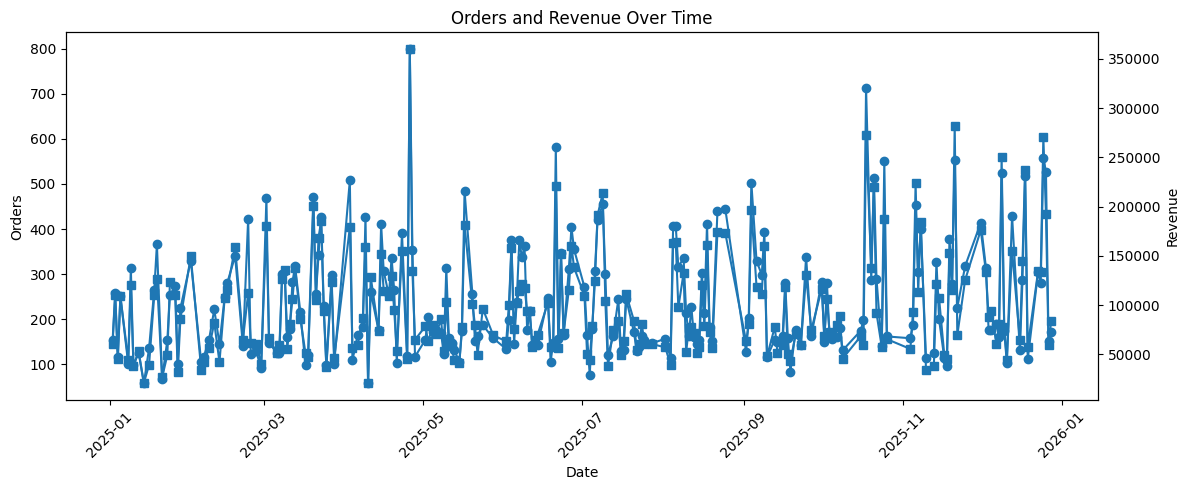

In [4]:
if date_col is not None and orders_col is not None and revenue_col is not None:
    time_df = (
        df.dropna(subset=[date_col])
          .groupby(date_col)[[orders_col, revenue_col]]
          .sum()
          .sort_index()
    )

    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(time_df.index, time_df[orders_col], marker="o", label="Orders")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Orders")
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()
    ax2.plot(time_df.index, time_df[revenue_col], marker="s", label="Revenue")
    ax2.set_ylabel("Revenue")

    ax1.set_title("Orders and Revenue Over Time")
    fig.tight_layout()
    plt.show()
else:
    print("Required time/order/revenue columns were not found.")


**Interpretation:** The line plot shows how order volume and revenue move over time. Peaks indicate stronger business periods, while simultaneous rises in orders and revenue suggest periods of increased demand. Comparing the two lines also helps identify dates where revenue changes without a proportional change in order volume.

## 5. Bar Chart — Performance by City

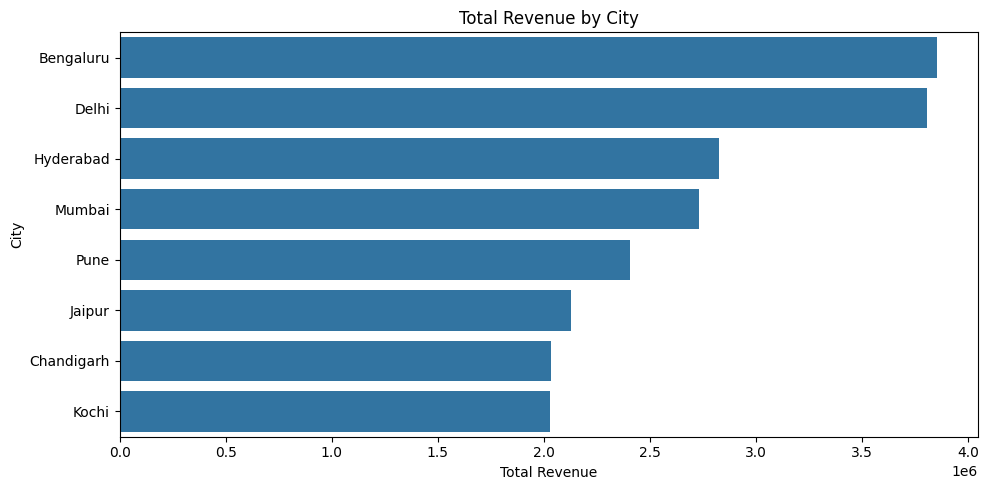

,Total_Revenue
City,
Bengaluru,"3,851,958.65"
Delhi,"3,808,183.88"
Hyderabad,"2,824,382.94"
Mumbai,"2,730,403.79"
Pune,"2,406,273.63"
Jaipur,"2,129,246.70"
Chandigarh,"2,034,416.22"
Kochi,"2,027,935.51"


In [5]:
if city_col is not None and revenue_col is not None:
    city_summary = (
        df.groupby(city_col)[revenue_col]
          .sum()
          .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(x=city_summary.values, y=city_summary.index)
    plt.title("Total Revenue by City")
    plt.xlabel("Total Revenue")
    plt.ylabel("City")
    plt.tight_layout()
    plt.show()

    display(city_summary.to_frame("Total_Revenue"))


**Interpretation:** Cities with longer bars contribute more total revenue. This comparison highlights geographic markets that are currently stronger and can help identify locations that may require additional operational or marketing attention.

## 6. Bar Chart — Performance by Cuisine

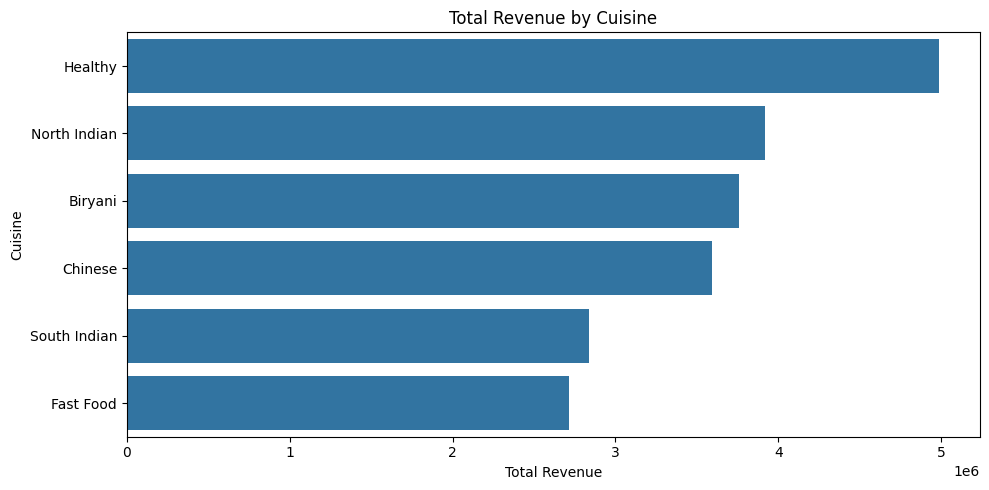

,Total_Revenue
Cuisine,
Healthy,"4,988,656.66"
North Indian,"3,915,404.79"
Biryani,"3,760,155.52"
Chinese,"3,594,364.34"
South Indian,"2,838,647.33"
Fast Food,"2,715,572.68"


In [6]:
if cuisine_col is not None and revenue_col is not None:
    cuisine_summary = (
        df.groupby(cuisine_col)[revenue_col]
          .sum()
          .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(x=cuisine_summary.values, y=cuisine_summary.index)
    plt.title("Total Revenue by Cuisine")
    plt.xlabel("Total Revenue")
    plt.ylabel("Cuisine")
    plt.tight_layout()
    plt.show()

    display(cuisine_summary.to_frame("Total_Revenue"))


**Interpretation:** The cuisine-level comparison reveals which food categories generate the greatest revenue. A cuisine with high revenue may reflect strong demand, higher average order values, or both.

## 7. Scatter Plot — Marketing Spend vs. Revenue

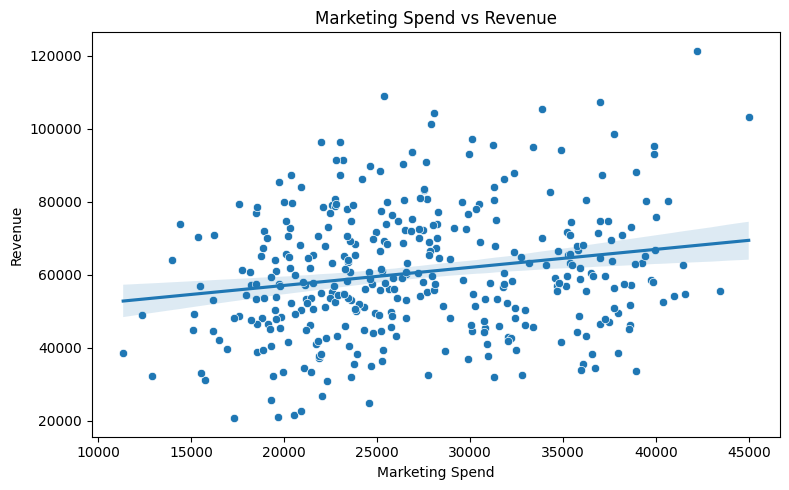

Correlation: 0.198


In [7]:
if marketing_col is not None and revenue_col is not None:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=marketing_col, y=revenue_col)
    sns.regplot(data=df, x=marketing_col, y=revenue_col, scatter=False)
    plt.title("Marketing Spend vs Revenue")
    plt.xlabel("Marketing Spend")
    plt.ylabel("Revenue")
    plt.tight_layout()
    plt.show()

    print("Correlation:", df[[marketing_col, revenue_col]].corr().iloc[0, 1].round(3))


**Interpretation:** The scatter plot shows whether higher marketing expenditure tends to be associated with higher revenue. An upward pattern indicates a positive relationship; however, the chart shows association rather than proving that marketing spend alone causes higher revenue.

## 8. Scatter Plot — Delivery Time vs Customer Rating

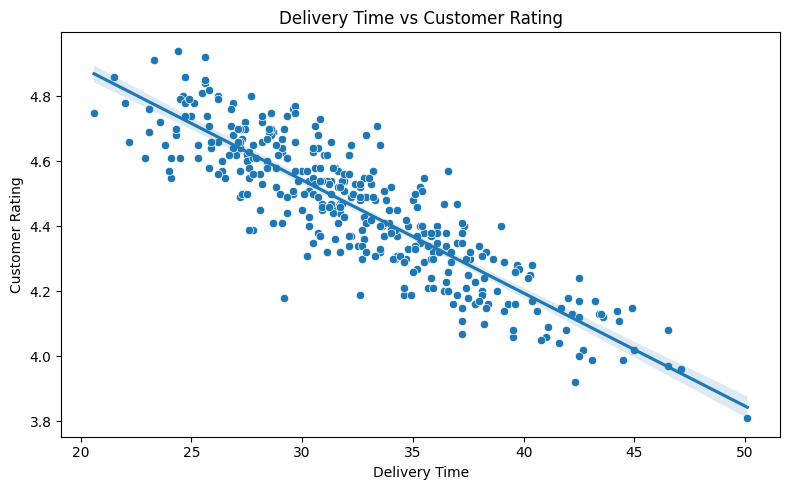

Correlation: -0.876


In [8]:
if delivery_col is not None and rating_col is not None:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=delivery_col, y=rating_col)
    sns.regplot(data=df, x=delivery_col, y=rating_col, scatter=False)
    plt.title("Delivery Time vs Customer Rating")
    plt.xlabel("Delivery Time")
    plt.ylabel("Customer Rating")
    plt.tight_layout()
    plt.show()

    print("Correlation:", df[[delivery_col, rating_col]].corr().iloc[0, 1].round(3))


**Interpretation:** This plot investigates whether slower deliveries are associated with lower customer ratings. A downward trend would indicate that longer delivery times generally coincide with weaker customer satisfaction.

## 9. Histogram — Distribution of Orders

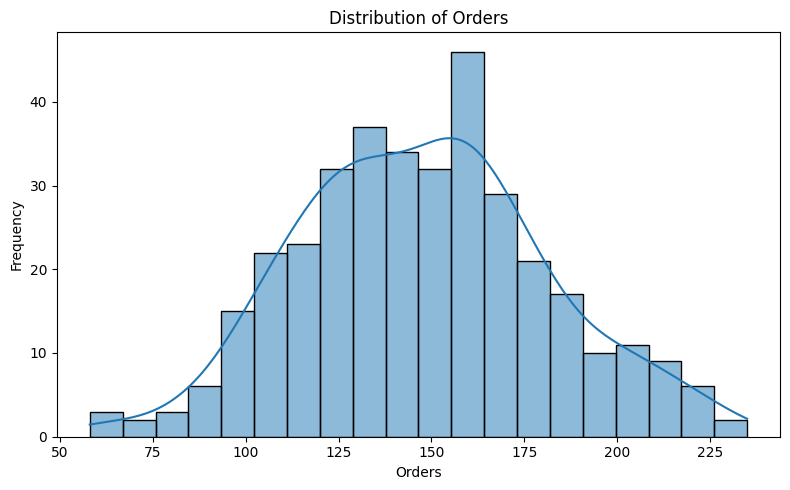

In [9]:
if orders_col is not None:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=orders_col, bins=20, kde=True)
    plt.title("Distribution of Orders")
    plt.xlabel("Orders")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


**Interpretation:** The histogram shows the typical range of order volumes and whether the distribution is symmetric or skewed. A long tail can indicate a smaller number of unusually busy periods.

## 10. Box Plot — Revenue Distribution

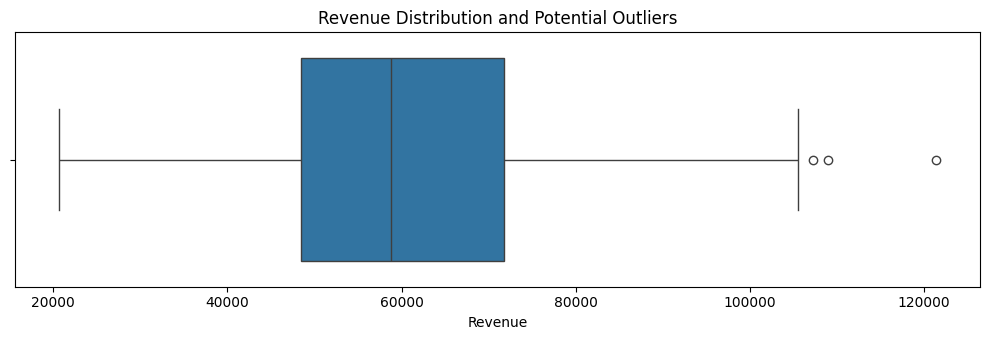

In [10]:
if revenue_col is not None:
    plt.figure(figsize=(10, 3.5))
    sns.boxplot(x=df[revenue_col])
    plt.title("Revenue Distribution and Potential Outliers")
    plt.xlabel("Revenue")
    plt.tight_layout()
    plt.show()


**Interpretation:** The box plot summarizes the median, spread, and potential outliers in revenue. Outlying observations represent unusually high or low revenue periods and may deserve further investigation.

## 11. Violin Plot — Customer Ratings by Cuisine

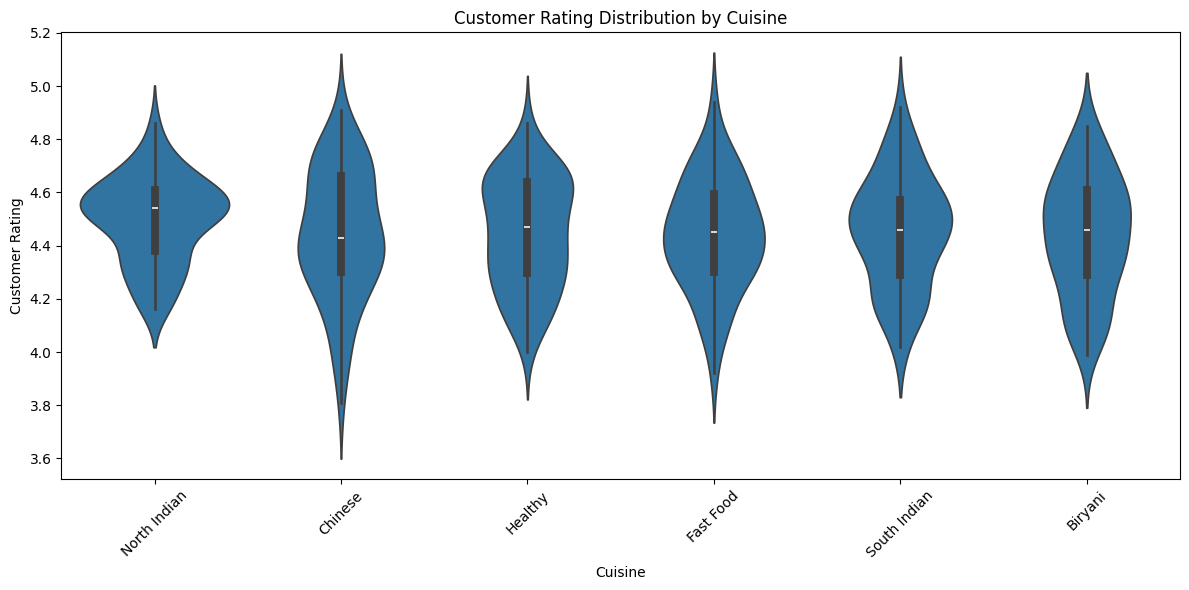

In [11]:
if cuisine_col is not None and rating_col is not None:
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=df, x=cuisine_col, y=rating_col)
    plt.title("Customer Rating Distribution by Cuisine")
    plt.xlabel("Cuisine")
    plt.ylabel("Customer Rating")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


**Interpretation:** Violin plots show both the spread and density of ratings for each cuisine. Wider areas indicate where observations are concentrated, making it possible to compare not only average ratings but also consistency.

## 12. Count Plot — Orders by Order Channel

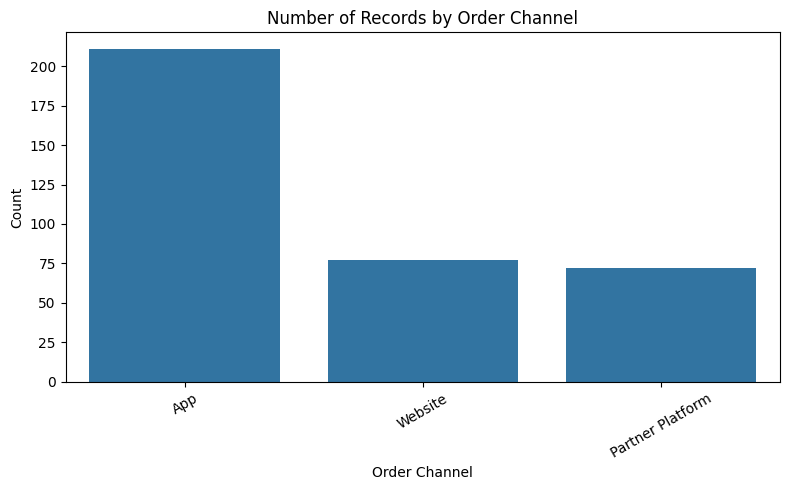

In [12]:
if channel_col is not None:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=channel_col, order=df[channel_col].value_counts().index)
    plt.title("Number of Records by Order Channel")
    plt.xlabel("Order Channel")
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


**Interpretation:** The count plot shows how frequently each ordering channel appears in the dataset. It identifies the dominant channels and provides context for comparing channel-level performance.

## 13. Weather vs Performance

,Revenue,Average_Revenue,Records
Weather,,,
Clear,"8,994,356.98","61,605.18",146
Cloudy,"5,633,965.72","59,935.81",94
Rainy,"4,512,017.74","60,160.24",75
Hot,"2,672,460.88","59,388.02",45


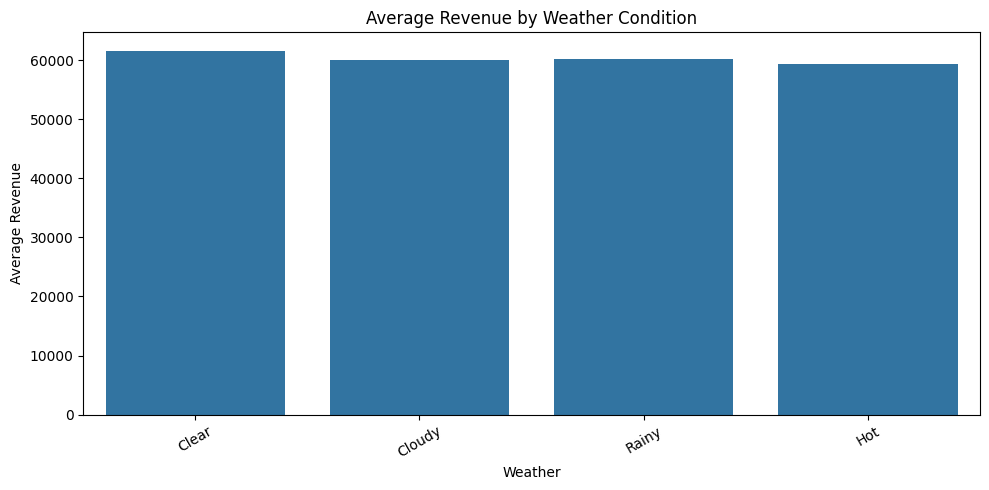

In [13]:
if weather_col is not None and revenue_col is not None:
    weather_summary = (
        df.groupby(weather_col)
          .agg(
              Revenue=(revenue_col, "sum"),
              Average_Revenue=(revenue_col, "mean"),
              Records=(revenue_col, "count")
          )
          .sort_values("Revenue", ascending=False)
    )

    display(weather_summary)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=weather_summary.reset_index(), x=weather_col, y="Average_Revenue")
    plt.title("Average Revenue by Weather Condition")
    plt.xlabel("Weather")
    plt.ylabel("Average Revenue")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


**Interpretation:** Comparing average revenue across weather conditions shows whether weather is associated with changes in business activity. The comparison should be interpreted together with the number of observations under each weather condition.

## 14. Order Channel vs Revenue

,Total_Revenue,Average_Revenue,Records
Order_Channel,,,
App,"13,435,579.94","63,675.73",211
Website,"4,471,108.12","58,066.34",77
Partner Platform,"3,906,113.26","54,251.57",72


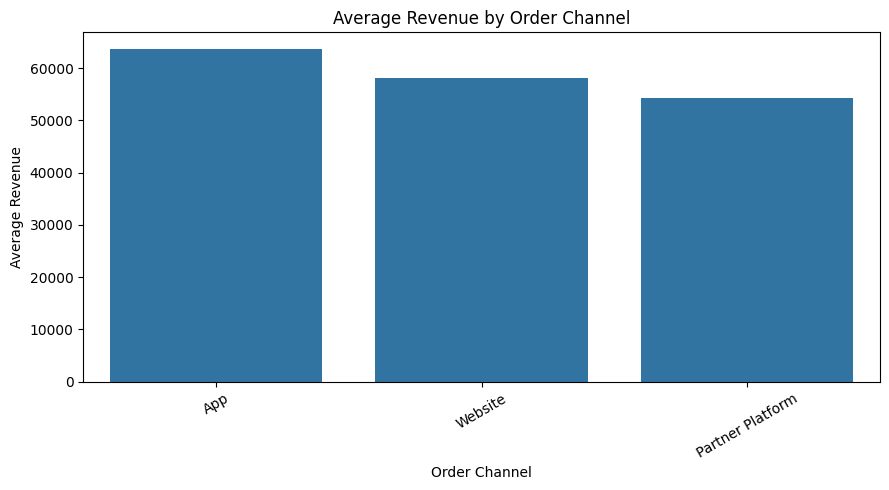

In [14]:
if channel_col is not None and revenue_col is not None:
    channel_summary = (
        df.groupby(channel_col)[revenue_col]
          .agg(["sum", "mean", "count"])
          .sort_values("sum", ascending=False)
          .rename(columns={"sum": "Total_Revenue", "mean": "Average_Revenue", "count": "Records"})
    )

    display(channel_summary)

    plt.figure(figsize=(9, 5))
    sns.barplot(data=channel_summary.reset_index(), x=channel_col, y="Average_Revenue")
    plt.title("Average Revenue by Order Channel")
    plt.xlabel("Order Channel")
    plt.ylabel("Average Revenue")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


**Interpretation:** This chart compares the revenue generated per record across ordering channels. The channel with the highest average revenue has stronger revenue per observation, while total revenue also depends on how frequently that channel is used.

## 15. Correlation Heatmap

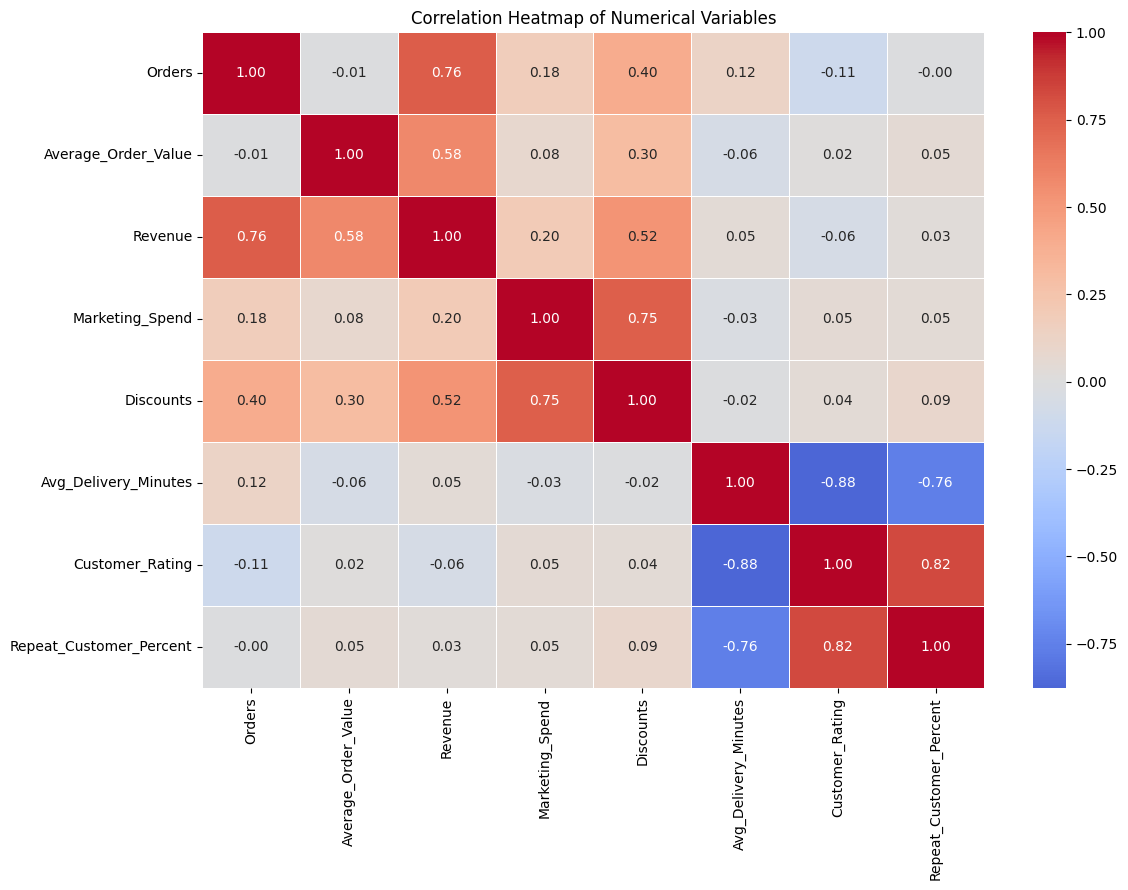

,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
Orders,1.00,-0.01,0.76,0.18,0.40,0.12,-0.11,-0.01
Average_Order_Value,-0.01,1.00,0.58,0.08,0.30,-0.06,0.02,0.05
Revenue,0.76,0.58,1.00,0.20,0.53,0.05,-0.06,0.03
Marketing_Spend,0.18,0.08,0.20,1.00,0.75,-0.03,0.05,0.05
Discounts,0.40,0.30,0.53,0.75,1.00,-0.02,0.04,0.09
Avg_Delivery_Minutes,0.12,-0.06,0.05,-0.03,-0.02,1.00,-0.88,-0.76
Customer_Rating,-0.11,0.02,-0.06,0.05,0.04,-0.88,1.00,0.82
Repeat_Customer_Percent,-0.01,0.05,0.03,0.05,0.09,-0.76,0.82,1.00


In [15]:
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

display(correlation_matrix.round(3))


**Interpretation:** The heatmap provides an overall view of linear relationships among numerical variables. Strong positive values indicate variables that tend to increase together, while strong negative values indicate inverse relationships. Correlation does not establish causation.

## 16. Automatic Identification of Strongest Correlations

In [16]:
corr_pairs = (
    correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Strongest absolute correlations:")
display(corr_pairs.head(10).to_frame("Correlation"))


Strongest absolute correlations:


,,Correlation
Avg_Delivery_Minutes,Customer_Rating,-0.88
Customer_Rating,Repeat_Customer_Percent,0.82
Avg_Delivery_Minutes,Repeat_Customer_Percent,-0.76
Orders,Revenue,0.76
Marketing_Spend,Discounts,0.75
Average_Order_Value,Revenue,0.58
Revenue,Discounts,0.52
Orders,Discounts,0.40
Average_Order_Value,Discounts,0.30
Revenue,Marketing_Spend,0.20


## 17. Optional Performance Comparison Table

In [17]:
# Create a compact performance summary when the relevant columns are available.
group_col = city_col if city_col is not None else cuisine_col

if group_col is not None:
    agg_dict = {}
    if orders_col is not None:
        agg_dict["Orders"] = (orders_col, "sum")
    if revenue_col is not None:
        agg_dict["Revenue"] = (revenue_col, "sum")
    if profit_col is not None:
        agg_dict["Profit"] = (profit_col, "sum")
    if rating_col is not None:
        agg_dict["Avg_Rating"] = (rating_col, "mean")

    if agg_dict:
        performance = df.groupby(group_col).agg(**agg_dict).sort_values(
            "Revenue" if "Revenue" in agg_dict else list(agg_dict.keys())[0],
            ascending=False
        )
        display(performance)


,Orders,Revenue,Avg_Rating
City,,,
Bengaluru,9394,"3,851,958.65",4.43
Delhi,9288,"3,808,183.88",4.41
Hyderabad,7140,"2,824,382.94",4.47
Mumbai,6633,"2,730,403.79",4.42
Pune,5812,"2,406,273.63",4.47
Jaipur,4931,"2,129,246.70",4.48
Chandigarh,5002,"2,034,416.22",4.49
Kochi,4953,"2,027,935.51",4.46


## 18. Summary of Important Findings

Based on the visualizations, the main business questions to discuss in the final submission are:

1. **Time trend:** Identify the periods where orders and revenue peak or fall and check whether both metrics move together.
2. **Geographic performance:** Compare the highest- and lowest-revenue cities to understand geographic concentration.
3. **Cuisine performance:** Identify the cuisines with the strongest revenue contribution and compare their rating distributions.
4. **Marketing effectiveness:** Examine the direction and strength of the marketing-spend/revenue relationship without interpreting correlation as causation.
5. **Delivery experience:** Look for a negative relationship between delivery time and customer ratings, which may indicate that delivery efficiency influences customer satisfaction.
6. **Weather effect:** Compare average revenue under different weather conditions while considering unequal numbers of observations.
7. **Channel mix:** Identify the dominant order channels and compare their average revenue.
8. **Overall relationships:** Use the correlation heatmap to identify the strongest numerical relationships and select the most meaningful ones for business discussion.

### Final conclusion
The visualization portfolio combines trend, comparison, distribution, relationship, and correlation charts to provide a multidimensional view of food-delivery performance. The strongest conclusions should be based on the actual patterns visible in the charts and supported by the accompanying summary tables rather than by any single visualization.
